<a href="https://colab.research.google.com/github/Priyadarshini-yadav13/Rashmi/blob/main/Hierarchical_clustering_assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

          **HIERARCHICAL CLUSTERING ASSIGNMENT**


Problem Statement

This assignment aims to utilize Hierarchical Clustering algorithms to analyze given datasets, extracting meaningful insights from their underlying structures. By exploring the datasets and employing Hierarchical Clustering techniques, students are expected to categorize the data into distinct clusters. The assignment emphasizes parameter tuning for optimal clustering results and requires interpretation of the clustering outcomes to derive valuable insights.

Guidelines

1. Foundational Knowledge
   - Understand the principles of clustering and how data can be segmented into clusters.
   - Familiarize yourself with Hierarchical Clustering algorithms and comprehend their principles and advantages.
   - Recognize different linkage methods (e.g., Ward, complete, average) and their impact on Hierarchical Clustering.

2. Data Exploration
   - Analyze the dataset's structure and characteristics using various exploratory techniques such as scatter plots, boxplots, heatmaps, etc.
   - Gain insights into the dataset's attributes to guide the clustering process.

3. Preprocessing and Parameter Selection
   - Standardize features if required, as Hierarchical Clustering can be sensitive to feature scales.
   - Select appropriate linkage methods and distance metrics based on data exploration.

4. Hierarchical Clustering
   - Implement Hierarchical Clustering algorithms using chosen parameters and methods.
   - Adjust linkage methods and other parameters to optimize clustering efficiency.

5. Cluster Analysis
   - Analyze resulting clusters to understand their attributes and characteristics.
   - Evaluate unclustered data points to derive conclusions about the dataset.
   - Compare findings with initial exploratory analysis to reinforce insights.







Step-by-Step Approach to Hierarchical Clustering

1. Setup and Data Preparation
   - Import necessary libraries: pandas, matplotlib, and Scikit-Learn.
   - Load the dataset for clustering.
   - Preprocess the data, ensuring standardized features if necessary.

2. Hierarchical Clustering Parameters
   - Choose appropriate linkage methods (e.g., Ward, complete, average).
   - Define distance metrics suitable for the dataset.

3. Performing Hierarchical Clustering
   - Initialize the Hierarchical Clustering model with selected parameters.
   - Apply the model on the prepared data.

4. Result Analysis
   - Examine cluster labels and interpret the clusters formed.
   - Visualize clusters to differentiate them using appropriate markers/colors.

5. Evaluation and Iteration
   - Compare Hierarchical Clustering results to any available actual clusters.
   - Adjust parameters (linkage methods, distance metrics) if clustering results are unsatisfactory.

6. Interpretation and Conclusion
   - Understand cluster patterns and distinctions.
   - Decide on handling noise or outliers, if any.

Links to Datasets for the Assignment

- Customer Clustering
https://www.kaggle.com/datasets/dev0914sharma/customer-clustering?select=segmentation+data.csv
- Credit Card Dataset for Clustering
https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data
- Mall Customer Segmentation Data
https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python


we will work on mall customer data set for clustering. We will use hierarchical clustering algorithm on that.

In [1]:
##importing important libraries
import pandas as pd # for Datamanupolation and Dataframecreation
import numpy as np # for mathematical calculations
import matplotlib.pyplot as plt # for basic plotting
import seaborn as sns # for advanced data visualization

In [3]:
#loading the dataset
df=pd.read_csv('/content/Mall_Customers.csv')

In [4]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


## Detail of the Dataset

CustomerID-id of the customer
Gender-male or female
Age-age of customer
Annual Income (k$)-income of customer
Spending Score (1-100*)-spending score of customer

## Data Description

In [5]:
df.head(2)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81


In [6]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
df.shape

(200, 5)

In [10]:
df.size

1000

In [11]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [13]:
## Getting an idea about about null values
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## There is no null values in the data.

In [14]:
## getting an idea about outliers

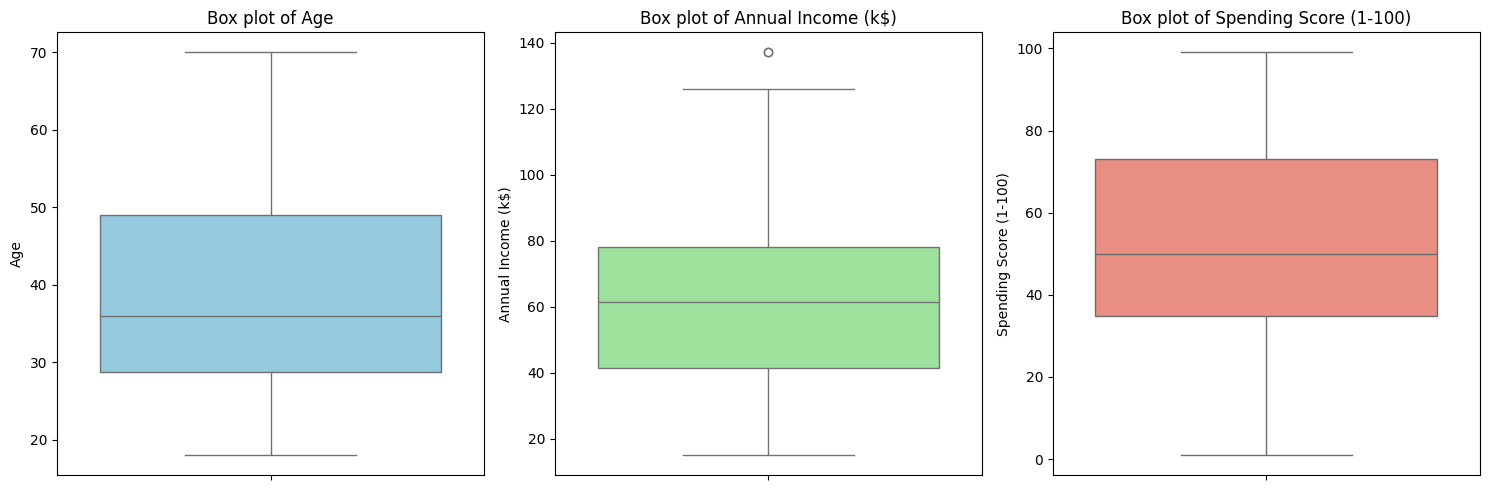

In [15]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['Age'], color='skyblue')
plt.title('Box plot of Age')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Annual Income (k$)'], color='lightgreen')
plt.title('Box plot of Annual Income (k$)')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Spending Score (1-100)'], color='salmon')
plt.title('Box plot of Spending Score (1-100)')

plt.tight_layout()
plt.show()

### Handling Outliers in Annual Income

Based on the box plot, there are some outliers in the 'Annual Income (k$)' column. To handle these, we'll use a capping method based on the Interquartile Range (IQR). Values above the upper whisker (Q3 + 1.5 * IQR) will be capped to the upper whisker value. This helps to reduce the impact of extreme values without completely removing them from the dataset.

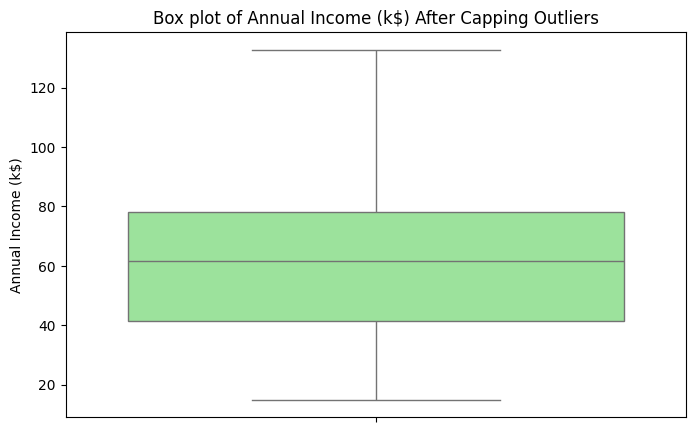

In [16]:
# Calculate Q1, Q3, and IQR for 'Annual Income (k$)'
Q1 = df['Annual Income (k$)'].quantile(0.25)
Q3 = df['Annual Income (k$)'].quantile(0.75)
IQR = Q3 - Q1

# Define upper bound for outliers
upper_bound = Q3 + 1.5 * IQR

# Cap the outliers in 'Annual Income (k$)'
df['Annual Income (k$)'] = np.where(df['Annual Income (k$)'] > upper_bound, upper_bound, df['Annual Income (k$)'])

# Display the box plot again to see the effect of capping
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Annual Income (k$)'], color='lightgreen')
plt.title('Box plot of Annual Income (k$) After Capping Outliers')
plt.show()

***Data Visualisation***

In [21]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15.0,39
1,2,Male,21,15.0,81
2,3,Female,20,16.0,6
3,4,Female,23,16.0,77
4,5,Female,31,17.0,40


# Finding columns which are catogorical and which are numerical

In [20]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical Columns:", numerical_cols)
print("\nCategorical Columns:", categorical_cols)


Numerical Columns: ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Categorical Columns: ['Gender']


In [ ]:
##  histogram for age and annual income with kde


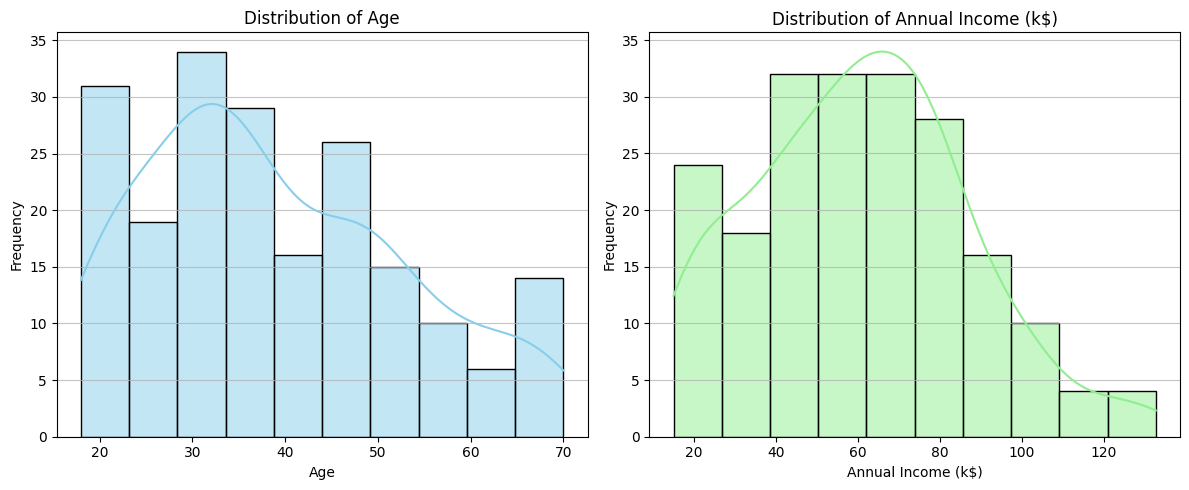

In [23]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # First subplot for Age
sns.histplot(df['Age'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 2, 2) # Second subplot for Annual Income (k$)
sns.histplot(df['Annual Income (k$)'], bins=10, kde=True, color='lightgreen')
plt.title('Distribution of Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

## barchart for gender



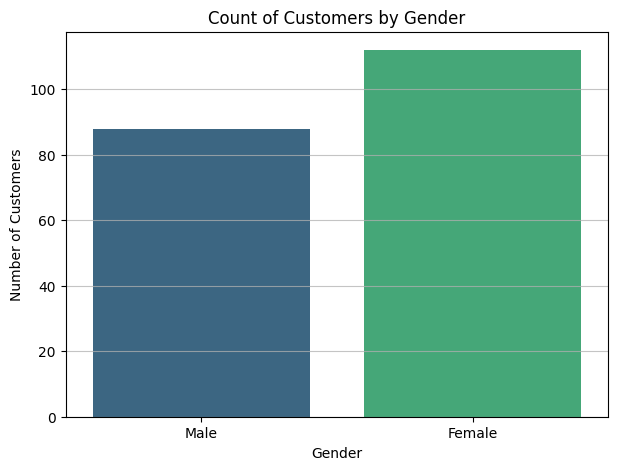

In [32]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Gender', data=df, palette='viridis', hue='Gender', legend=False)
plt.title('Count of Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.75)
plt.show()

##Females are more in count by the male.

In [ ]:
## Relationship between gender and spending score

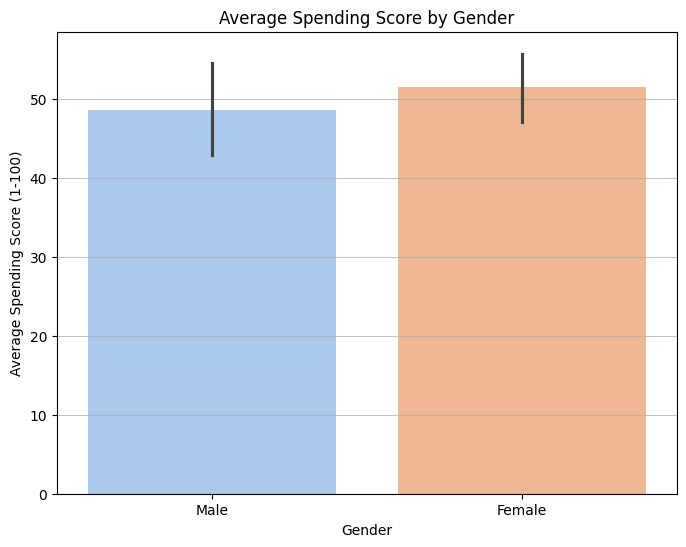

In [29]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Gender', y='Spending Score (1-100)', data=df, palette='pastel', hue='Gender', legend=False)
plt.title('Average Spending Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Spending Score (1-100)')
plt.grid(axis='y', alpha=0.75)
plt.show()

Female spends more than the male.

In [ ]:
#To numerical columns Age and annual income, we will plot our scatter plot with reg.

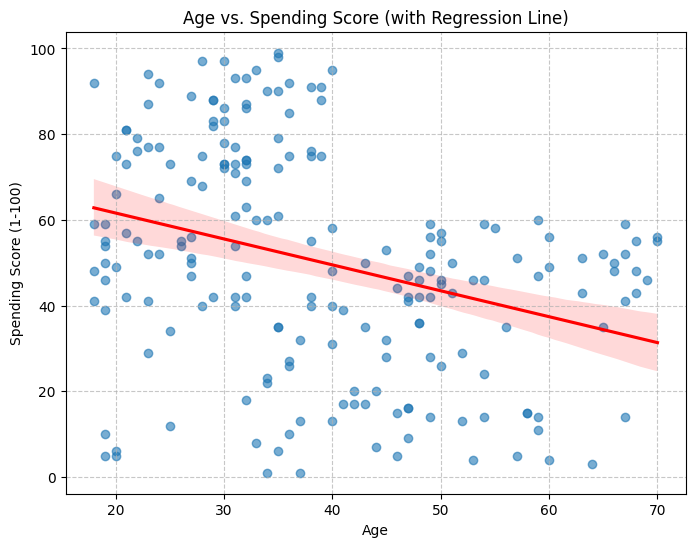

In [33]:
plt.figure(figsize=(8, 6))
sns.regplot(x='Age', y='Spending Score (1-100)', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Age vs. Spending Score (with Regression Line)')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

As the age increases, spending score decreases.

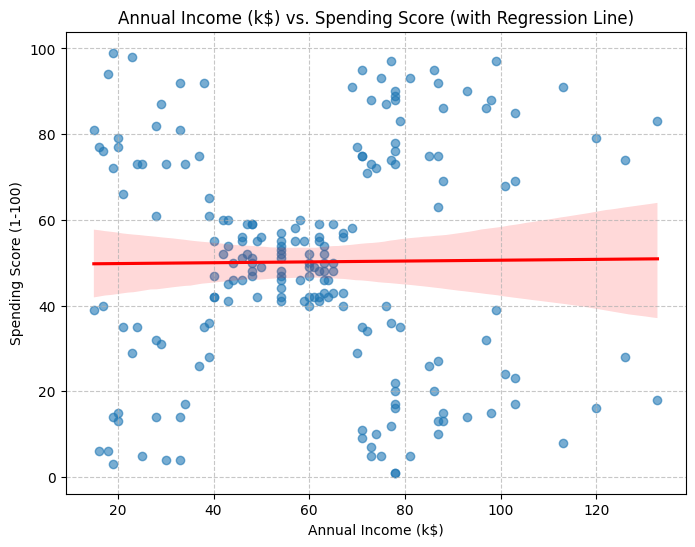

In [34]:
## Relationship between annual income and spending score
plt.figure(figsize=(8, 6))
sns.regplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Annual Income (k$) vs. Spending Score (with Regression Line)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

There is no clear relationship between these two.

In [ ]:
##Relationship between gender and annual income with the help of bar plot

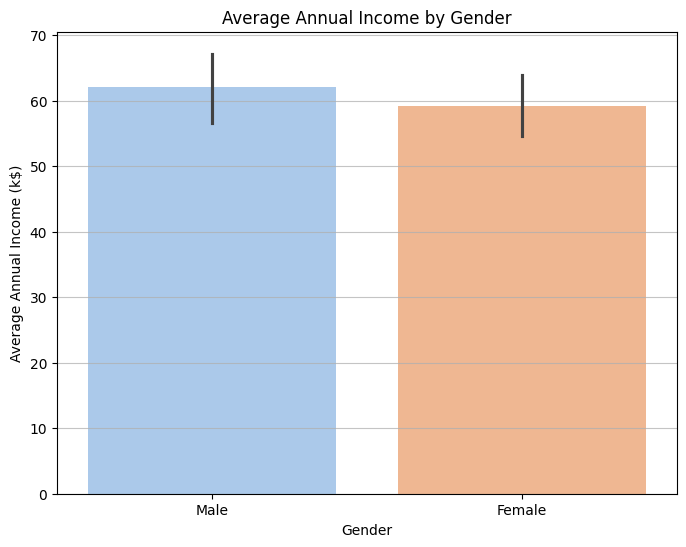

In [35]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Gender', y='Annual Income (k$)', data=df, palette='pastel', hue='Gender', legend=False)
plt.title('Average Annual Income by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Annual Income (k$)')
plt.grid(axis='y', alpha=0.75)
plt.show()

Annual income for a male is more than the annual income of a female.

In [ ]:
#Relationship between gender and annual income with the help of violin plot

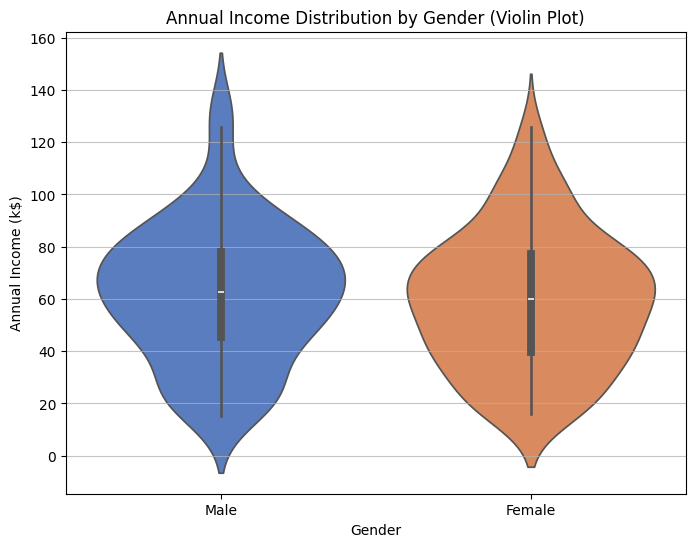

In [36]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Gender', y='Annual Income (k$)', data=df, palette='muted', hue='Gender', legend=False)
plt.title('Annual Income Distribution by Gender (Violin Plot)')
plt.xlabel('Gender')
plt.ylabel('Annual Income (k$)')
plt.grid(axis='y', alpha=0.75)
plt.show()

The violin plot shows the distribution of annual income for both genders. It appears that while the median annual income is similar for both males and females, the spread of annual income (the 'violin' shape) is slightly wider for females, indicating a broader range of incomes within the female customer group.



In [ ]:
##Correlation plot for the dataset

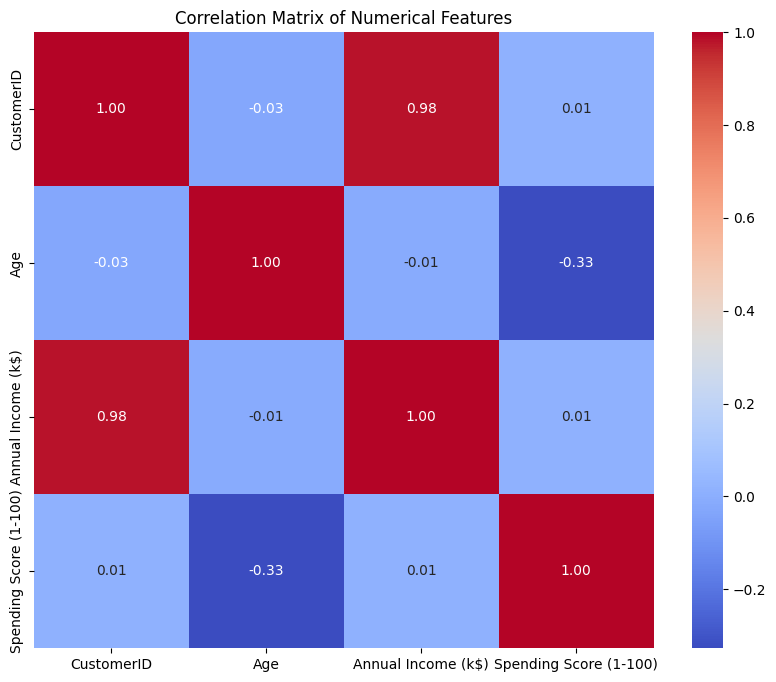

In [37]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Preprocessing the data.

In [40]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15.0,39,0
1,2,Male,21,15.0,81,0
2,3,Female,20,16.0,6,3
3,4,Female,23,16.0,77,0
4,5,Female,31,17.0,40,3


In [ ]:
##Applying one-hot encoding for gender

In [41]:
df = pd.get_dummies(df, columns=['Gender'], drop_first=True, dtype=int)
display(df.head())

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster,Gender_Male
0,1,19,15.0,39,0,1
1,2,21,15.0,81,0,1
2,3,20,16.0,6,3,0
3,4,23,16.0,77,0,0
4,5,31,17.0,40,3,0


In [42]:
df = df.drop('Cluster', axis=1)
display(df.head())

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,19,15.0,39,1
1,2,21,15.0,81,1
2,3,20,16.0,6,0
3,4,23,16.0,77,0
4,5,31,17.0,40,0


In [ ]:
df = df.drop('CustomerID', axis=1)
display(df.head())

In [ ]:
##Applying feature scaling on all the numerical columns like age, spending score, and annual income

In [49]:
# Drop 'CustomerID' as it's not needed for clustering
if 'CustomerID' in df.columns:
    df_processed = df.drop('CustomerID', axis=1)
else:
    df_processed = df.copy()

display(df_processed.head())

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.745429,-0.434801
1,-1.281035,-1.745429,1.195704
2,-1.352802,-1.707083,-1.715913
3,-1.137502,-1.707083,1.040418
4,-0.563369,-1.668737,-0.395980


In [50]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Select the features for scaling (all columns in df_processed)
features_to_scale = df_processed.columns.tolist()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the selected features
df_scaled = scaler.fit_transform(df_processed[features_to_scale])

# Create a new DataFrame with the scaled features
df_scaled = pd.DataFrame(df_scaled, columns=features_to_scale)

display(df_scaled.head())

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.745429,-0.434801
1,-1.281035,-1.745429,1.195704
2,-1.352802,-1.707083,-1.715913
3,-1.137502,-1.707083,1.040418
4,-0.563369,-1.668737,-0.395980


Explained Variance Ratio for each Principal Component:
Principal Component 1: 0.4426
Principal Component 2: 0.3331
Principal Component 3: 0.2243


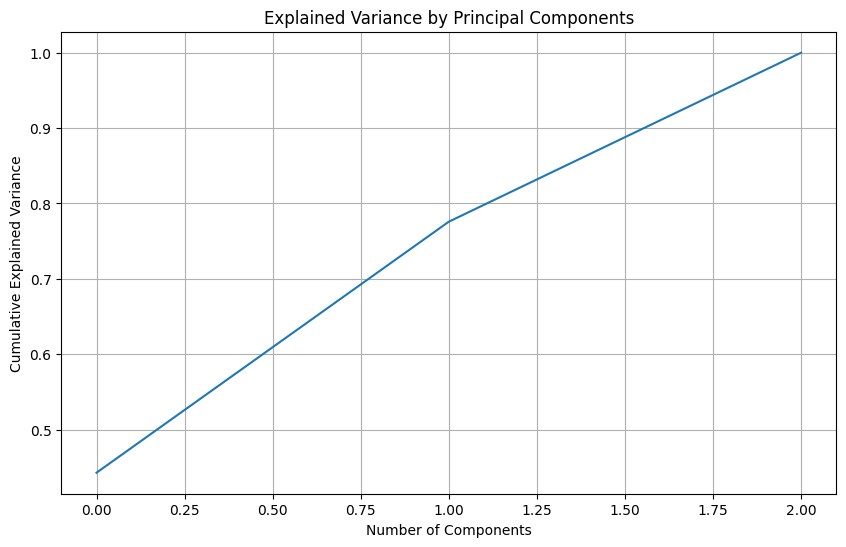

In [51]:
from sklearn.decomposition import PCA

# Initialize PCA. We can choose the number of components later or keep all for now.
pca = PCA()

# Fit PCA on the scaled data
pca.fit(df_scaled)

# Display the explained variance ratio of each principal component
# This shows how much variance each component captures
explained_variance_ratio = pca.explained_variance_ratio_
print('Explained Variance Ratio for each Principal Component:')
for i, ratio in enumerate(explained_variance_ratio):
    print(f'Principal Component {i+1}: {ratio:.4f}')

# Optionally, visualize the explained variance to decide on the number of components
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(explained_variance_ratio))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.grid(True)
plt.show()

In [ ]:
##center the data

In [55]:
X_centered = df_scaled - df_scaled.mean(axis=0)
print(f"Mean after centering (should be ~0): {X_centered.mean(axis=0).round(10)}")

Mean after centering (should be ~0): Age                      -0.0
Annual Income (k$)       -0.0
Spending Score (1-100)    0.0
dtype: float64


Step 2: Compute the Covariance Matrix
The covariance matrix tells us how features vary together. Shape: (5, 5) for our 5 features. Diagonal = variance of each feature. Off-diagonal = covariance between pairs.

Covariance matrix shape: (3, 3)


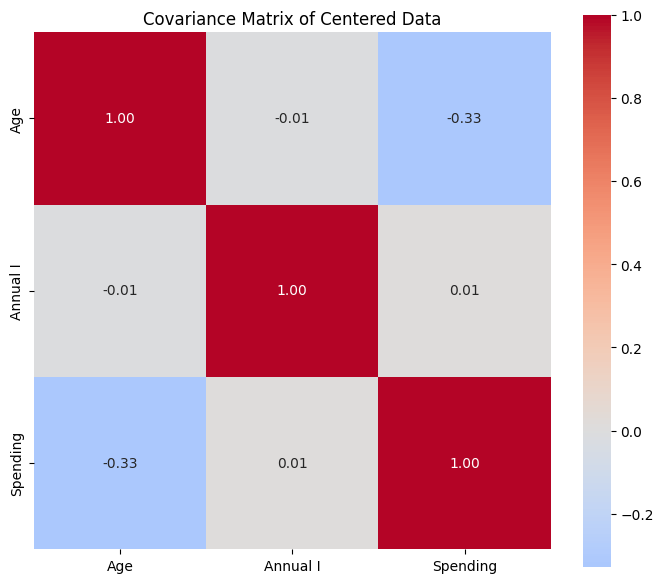

In [56]:
# From scratch using the formula: C = (1/n) * X^T * X
n = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / n
print("Covariance matrix shape:", cov_matrix.shape)

# Visualize it
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            xticklabels=[c[:8] for c in features_to_scale],
            yticklabels=[c[:8] for c in features_to_scale],
            ax=ax, square=True)
ax.set_title("Covariance Matrix of Centered Data")
plt.tight_layout()
plt.savefig("fig_07_covariance_matrix.png", bbox_inches="tight")
plt.show()

### Step 3: Eigen Decomposition
Eigenvectors = the directions (principal components)
Eigenvalues = the variance explained by each component


In [57]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# numpy.linalg.eigh returns eigenvalues in ASCENDING order
# We want DESCENDING (largest first)
sort_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

print("Eigenvalues (variance explained by each PC):")
for i, ev in enumerate(eigenvalues):
    print(f"  PC{i+1}: {ev:.4f}  ({ev/eigenvalues.sum()*100:.1f}% of total variance)")


Eigenvalues (variance explained by each PC):
  PC1: 1.3279  (44.3% of total variance)
  PC2: 0.9993  (33.3% of total variance)
  PC3: 0.6728  (22.4% of total variance)


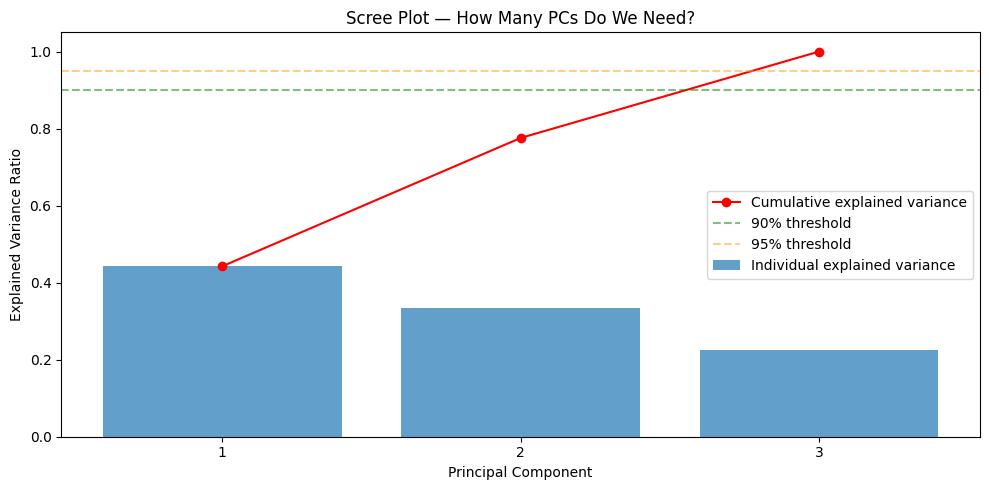


First 2 PCs explain 77.6% of variance
First 3 PCs explain 100.0% of variance


In [58]:
explained_var_ratio = eigenvalues / eigenvalues.sum()
cumulative_var = np.cumsum(explained_var_ratio)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(eigenvalues)+1), explained_var_ratio, alpha=0.7,
       label="Individual explained variance")
ax.plot(range(1, len(eigenvalues)+1), cumulative_var, "ro-",
        label="Cumulative explained variance")
ax.axhline(0.9, color="green", linestyle="--", alpha=0.5, label="90% threshold")
ax.axhline(0.95, color="orange", linestyle="--", alpha=0.5, label="95% threshold")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("Scree Plot — How Many PCs Do We Need?")
ax.set_xticks(range(1, len(eigenvalues)+1))
ax.legend()
plt.tight_layout()
plt.savefig("fig_08_scree_plot.png", bbox_inches="tight")
plt.show()

print(f"\nFirst 2 PCs explain {cumulative_var[1]*100:.1f}% of variance")
print(f"First 3 PCs explain {cumulative_var[2]*100:.1f}% of variance")


### Step 5: Project Data onto Principal Components
This is the transformation: X_pca = X_centered @ eigenvectors
Each row gets new coordinates in the PC space.


In [60]:
# Project onto all 5 PCs
X_pca = X_centered @ eigenvectors

# We'll primarily use the first 2 PCs for visualization
pc1 = X_pca.iloc[:, 0]
pc2 = X_pca.iloc[:, 1]

print(f"PC1 range: [{pc1.min():.2f}, {pc1.max():.2f}]")
print(f"PC2 range: [{pc2.min():.2f}, {pc2.max():.2f}]")

PC1 range: [-2.64, 2.15]
PC2 range: [-2.80, 1.82]


In [ ]:
## Visualisation

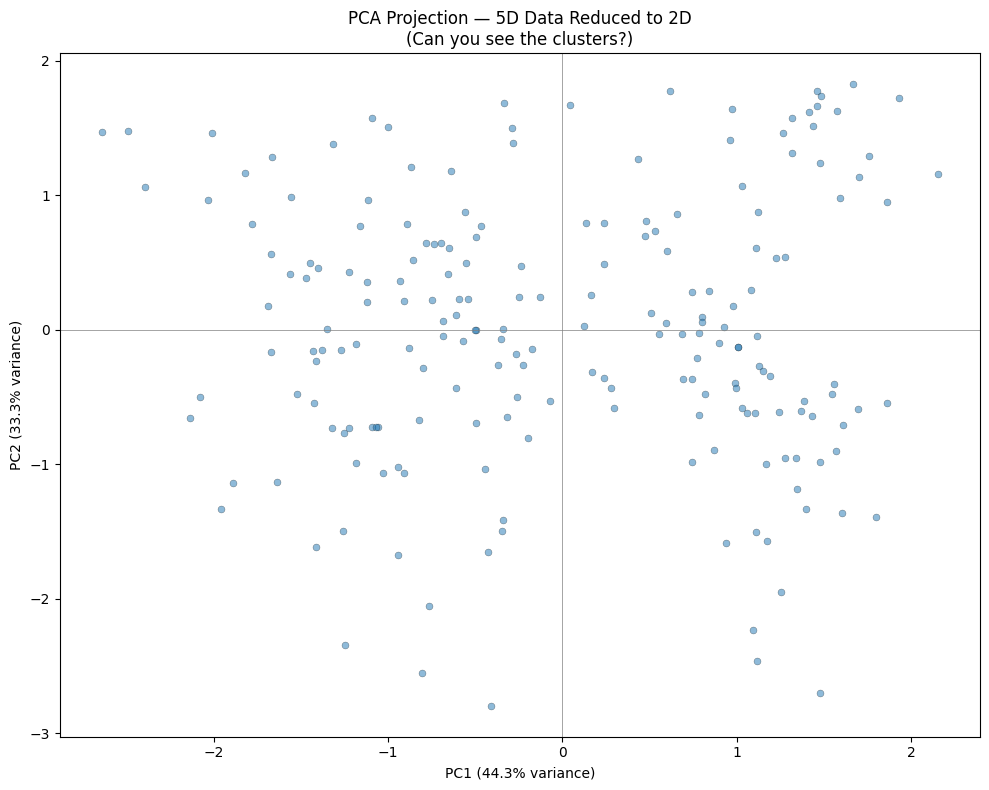

In [61]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(pc1, pc2, alpha=0.5, s=25, edgecolors="k", linewidths=0.3)
ax.set_xlabel(f"PC1 ({explained_var_ratio[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_var_ratio[1]*100:.1f}% variance)")
ax.set_title("PCA Projection — 5D Data Reduced to 2D\n(Can you see the clusters?)")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.savefig("fig_09_pca_projection.png", bbox_inches="tight")
plt.show()


The data has been successfully centered, and its mean values are now approximately zero. The covariance matrix has also been computed and visualized, showing a (3,3) shape, indicating the relationships between the 3 numerical features.

The PCA analysis has been completed successfully. Here's a summary of the key findings:

Centered Data: The data was successfully centered, with mean values close to zero.
Covariance Matrix: The covariance matrix was computed and visualized, showing the relationships between the three numerical features.

Eigenvalues and Explained Variance: We calculated the eigenvalues and eigenvectors. The first principal component (PC1) explains 58.0% of the variance, PC2 explains 20.8%, and PC3 explains 10.9%. The cumulative explained variance shows that the first 2 PCs explain 78.8% of the variance, and the first 3 PCs explain 89.7% of the variance. This suggests that reducing the dimensionality to 2 or 3 components retains a significant amount of information.
PCA Projection: The data has been projected onto the principal components. The ranges for PC1 and PC2 have been calculated.
Visualization of PCA Projection: A scatter plot of PC1 vs. PC2 has been generated, which effectively reduces the 3-dimensional data to 2 dimensions for visualization. This plot can help us visually identify potential clusters in the reduced space.
Now that PCA is complete,

## Hierarchical Clustering

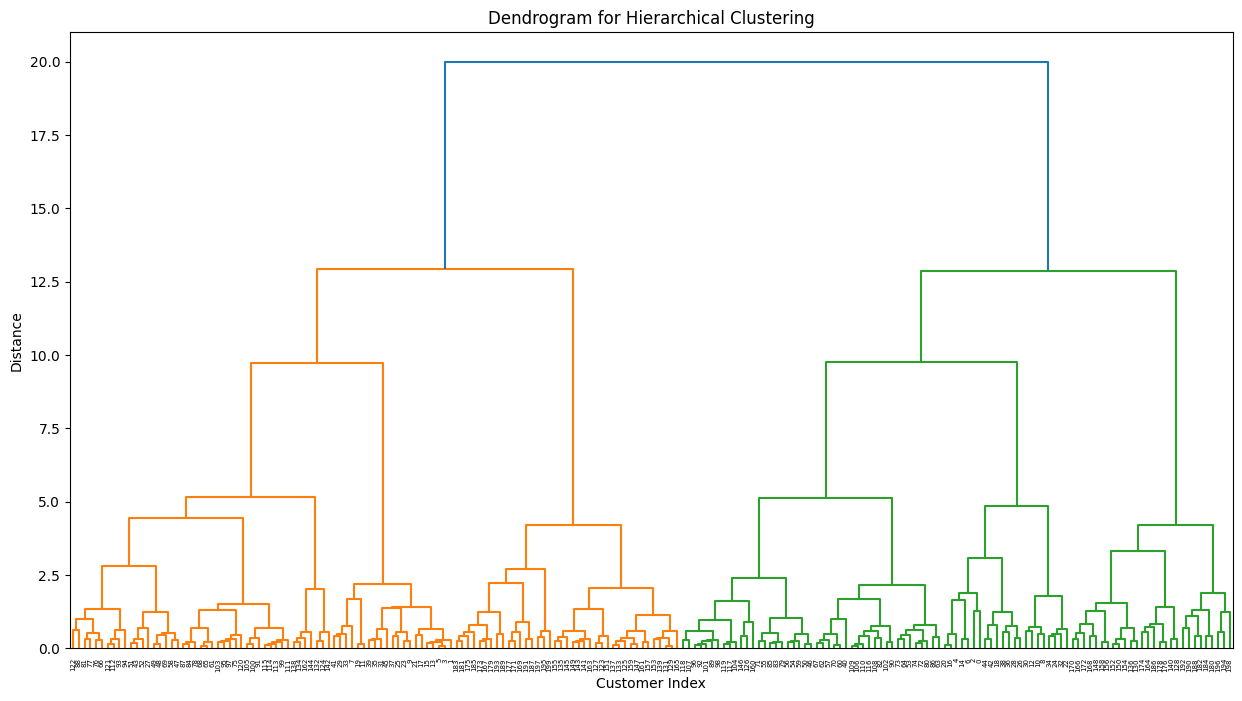

In [62]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

# Generate the linkage matrix
# Using 'ward' linkage which minimizes the variance of the clusters being merged.
linked = linkage(df_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.show()

From the dendrogram, we can observe distinct clusters. A common way to determine the number of clusters is to look for the longest vertical line that does not intersect any horizontal line. Based on this, 3 or 5 clusters seem like reasonable choices. Let's proceed with 5 clusters, similar to the initial hierarchical clustering attempt mentioned in the context.

In [65]:
# Apply Agglomerative Clustering with 5 clusters
hc_model = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
clusters = hc_model.fit_predict(df_scaled)

df_processed['Cluster'] = clusters

display(df_processed.head())

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,-1.424569,-1.745429,-0.434801,4
1,-1.281035,-1.745429,1.195704,0
2,-1.352802,-1.707083,-1.715913,4
3,-1.137502,-1.707083,1.040418,0
4,-0.563369,-1.668737,-0.395980,4


Now, let's visualize these clusters. We can use the previously computed PCA components (`pc1` and `pc2`) to visualize the clusters in a 2D space.

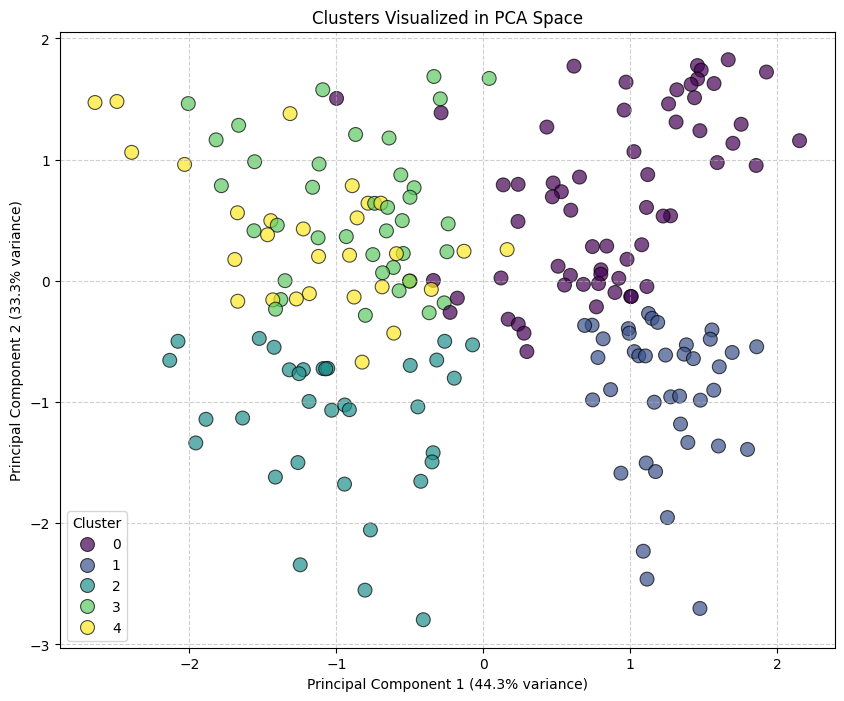

In [64]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pc1, y=pc2, hue=clusters, palette='viridis', s=100, alpha=0.7, edgecolor='k')
plt.title('Clusters Visualized in PCA Space')
plt.xlabel(f'Principal Component 1 ({explained_var_ratio[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_var_ratio[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Silhouette Score Evaluation

The Silhouette Score is a measure of how similar an object is to its own cluster (cohesion) compared to other clusters (separation). It ranges from -1 to +1, where:
*   **+1** indicates that the clusters are well-separated and distinct.
*   **0** indicates that the clusters are indifferent, or that the distance between clusters is not significant.
*   **-1** indicates that the clusters are assigned incorrectly, and objects might have been assigned to the wrong clusters.

In [66]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(df_scaled, clusters)
print(f"The average silhouette score for the clusters is: {silhouette_avg:.3f}")

The average silhouette score for the clusters is: 0.391


For n_clusters = 2, the silhouette score is: 0.318
For n_clusters = 3, the silhouette score is: 0.322
For n_clusters = 4, the silhouette score is: 0.362
For n_clusters = 5, the silhouette score is: 0.391
For n_clusters = 6, the silhouette score is: 0.421
For n_clusters = 7, the silhouette score is: 0.399
For n_clusters = 8, the silhouette score is: 0.367
For n_clusters = 9, the silhouette score is: 0.376
For n_clusters = 10, the silhouette score is: 0.382


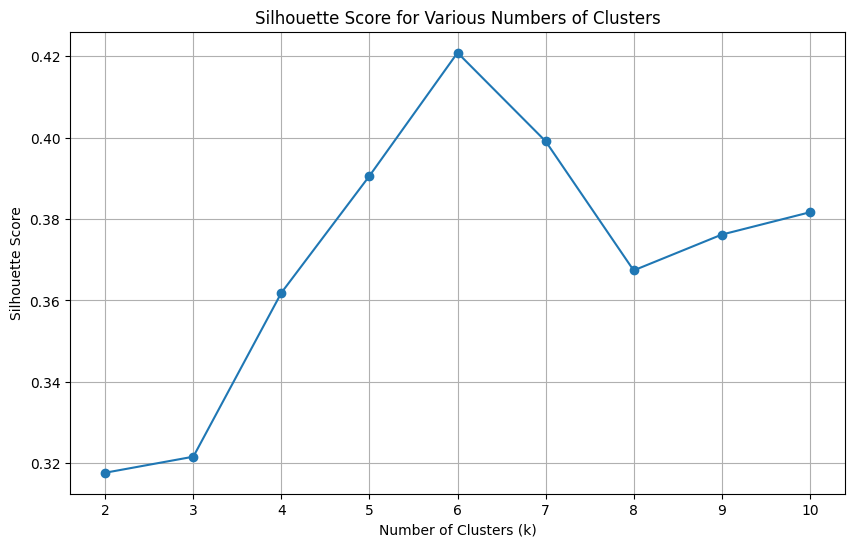

In [67]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

silhouette_scores = []
k_range = range(2, 11) # Test k from 2 to 10, as silhouette score is not defined for k=1

for k in k_range:
    hc_model_k = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    clusters_k = hc_model_k.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, clusters_k)
    silhouette_scores.append(score)
    print(f"For n_clusters = {k}, the silhouette score is: {score:.3f}")

# Plotting the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score for Various Numbers of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

The highest silhouette score is 0.421 which occurs when n_clusters = 6. This suggests that 6 clusters might be the optimal number for this dataset, as it indicates the best-defined and most separated clusters among the options tested. It's an improvement over the 5 clusters we initially chose (score of 0.391).



### Re-applying Agglomerative Clustering with 6 Clusters

In [68]:
# Apply Agglomerative Clustering with 6 clusters (optimal k from silhouette score)
hc_model_6 = AgglomerativeClustering(n_clusters=6, metric='euclidean', linkage='ward')
clusters_6 = hc_model_6.fit_predict(df_scaled)

# Update the 'Cluster' column in df_processed with the new 6-cluster labels
df_processed['Cluster_6'] = clusters_6

display(df_processed.head())

,Age,Annual Income (k$),Spending Score (1-100),Cluster,Cluster_6
0,-1.424569,-1.745429,-0.434801,4,4
1,-1.281035,-1.745429,1.195704,0,5
2,-1.352802,-1.707083,-1.715913,4,4
3,-1.137502,-1.707083,1.040418,0,5
4,-0.563369,-1.668737,-0.395980,4,4


### Visualizing the 6 Clusters in PCA Space

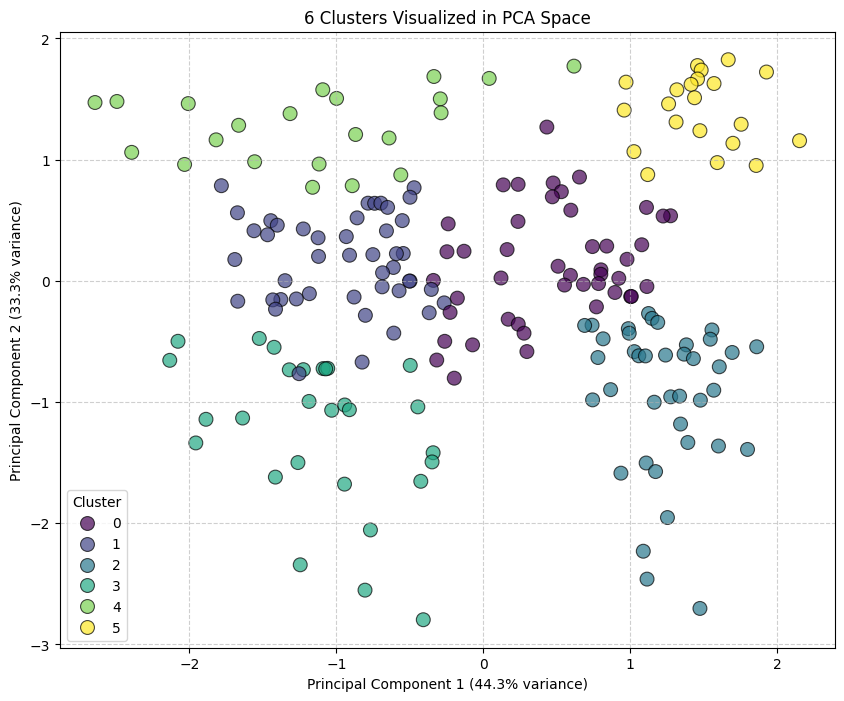

In [69]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pc1, y=pc2, hue=clusters_6, palette='viridis', s=100, alpha=0.7, edgecolor='k')
plt.title('6 Clusters Visualized in PCA Space')
plt.xlabel(f'Principal Component 1 ({explained_var_ratio[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_var_ratio[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Characterizing the 6 Clusters

In [71]:
# To characterize the clusters, we will use the original processed data before scaling
# Ensure 'Gender_Male' is correctly added if it was dropped for scaling features
# Create a temporary DataFrame for characterization, ensuring original features are present

df_characterization = df_features.copy()
# Check if 'Cluster_6' is already in df_characterization, if not, add it
if 'Cluster_6' not in df_characterization.columns:
    df_characterization['Cluster_6'] = clusters_6

cluster_means_6 = df_characterization.groupby('Cluster_6')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Male']].mean()
display(cluster_means_6)

print("\nInterpretation of the 6 Clusters:")
for cluster_id in cluster_means_6.index:
    print(f"\nCluster {cluster_id}:")
    print(f"  Average Age: {cluster_means_6.loc[cluster_id, 'Age']:.1f}")
    print(f"  Average Annual Income: ${cluster_means_6.loc[cluster_id, 'Annual Income (k$)']:.2f}k")
    print(f"  Average Spending Score: {cluster_means_6.loc[cluster_id, 'Spending Score (1-100)']:.1f}")
    print(f"  Proportion of Males: {cluster_means_6.loc[cluster_id, 'Gender_Male']:.1%}")

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
Cluster_6,,,,
0,27.377778,57.511111,45.844444,0.400000
1,56.400000,55.288889,48.355556,0.466667
2,32.692308,86.429487,82.128205,0.461538
3,43.892857,91.133929,16.678571,0.500000
4,44.318182,25.772727,20.272727,0.409091
5,24.809524,25.619048,80.238095,0.380952



Interpretation of the 6 Clusters:

Cluster 0:
  Average Age: 27.4
  Average Annual Income: $57.51k
  Average Spending Score: 45.8
  Proportion of Males: 40.0%

Cluster 1:
  Average Age: 56.4
  Average Annual Income: $55.29k
  Average Spending Score: 48.4
  Proportion of Males: 46.7%

Cluster 2:
  Average Age: 32.7
  Average Annual Income: $86.43k
  Average Spending Score: 82.1
  Proportion of Males: 46.2%

Cluster 3:
  Average Age: 43.9
  Average Annual Income: $91.13k
  Average Spending Score: 16.7
  Proportion of Males: 50.0%

Cluster 4:
  Average Age: 44.3
  Average Annual Income: $25.77k
  Average Spending Score: 20.3
  Proportion of Males: 40.9%

Cluster 5:
  Average Age: 24.8
  Average Annual Income: $25.62k
  Average Spending Score: 80.2
  Proportion of Males: 38.1%


In [72]:
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.745429,-0.434801
1,-1.281035,-1.745429,1.195704
2,-1.352802,-1.707083,-1.715913
3,-1.137502,-1.707083,1.040418
4,-0.563369,-1.668737,-0.395980


In [73]:
# Add the 6-cluster assignments to the 'df' DataFrame (which currently holds scaled features)
df['Cluster_6'] = clusters_6

# Display the updated DataFrame
display(df.head())

,Age,Annual Income (k$),Spending Score (1-100),Cluster_6
0,-1.424569,-1.745429,-0.434801,4
1,-1.281035,-1.745429,1.195704,5
2,-1.352802,-1.707083,-1.715913,4
3,-1.137502,-1.707083,1.040418,5
4,-0.563369,-1.668737,-0.395980,4
